# Sandbox - Likelihood

This notebook is used to prototype the likelihood function, used to generate all scenarios of use of the algorithm.

---

## Imports & Config

In [35]:
! pwd

/Users/simonlejoly/Documents/Work/mimosa/tests/identifiability


/opt/miniconda3/envs/mimosa/lib/python3.12/pty.py:95: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.



In [36]:
! export XLA_PYTHON_CLIENT_MEM_FRACTION=.25

In [37]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [38]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [39]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)
import jax.random as jr
import jax.numpy as jnp
from jax import vmap, jit, Array, grad

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

import numpy as np

from kernax import ZeroMean, ConstantMean, LinearMean, AffineMean
from kernax import SEKernel, VarianceKernel, sample_hps_from_normal_priors, BatchModule, config
#config.parameter_transform = "exp"

In [40]:
# Local imports
from mimosa.sampling import sample_gp
from likelihood_comps import *

In [41]:
key = jr.PRNGKey(42)

---

## GP identifiability - SE without noise

In [42]:
sample_jitter = jnp.array(1e-10)
nll_jitter = jnp.array(1e-3)

In [43]:
grid_range = (-3, 3)
nb_points = 200
grid = jnp.linspace(*grid_range, nb_points)[:, None]

In [44]:
kern_priors = {"variance":(2.5, .75), "length_scale": (1.5, .5)}
mean_priors = {"slope": (0., .25), "intercept": (0., 1.5)}

### 1 sample

In [45]:
kern = VarianceKernel(variance=1.) * SEKernel(length_scale=1.)
key, subkey1, subkey2 = jr.split(key, 3)
kern = sample_hps_from_normal_priors(subkey1, kern, kern_priors)
mean = AffineMean(slope=0., intercept=0.)
mean = sample_hps_from_normal_priors(subkey2, mean, mean_priors)
print(f"{kern}\n{mean}")

VarianceKernel(variance=2.59) * SEKernel(length_scale=1.40)
AffineMean(slope=0.31, intercept=-0.16)


In [46]:
key, subkey = jax.random.split(key)
vals = sample_gp(subkey, mean(grid), kern(grid), jitter=sample_jitter)
np.asarray(vals)

array([-0.42870073, -0.41338558, -0.39634626, -0.37767265, -0.3573548 ,
       -0.3353927 , -0.31189471, -0.28684129, -0.26032678, -0.23237195,
       -0.20304991, -0.17241692, -0.14051354, -0.10739424, -0.07317388,
       -0.03784302, -0.00150152,  0.0357467 ,  0.07389006,  0.11280326,
        0.15243476,  0.19272242,  0.23354835,  0.27488996,  0.3166203 ,
        0.35867757,  0.40096664,  0.44342014,  0.48594909,  0.52848436,
        0.57087968,  0.6131494 ,  0.65513627,  0.69680206,  0.73801557,
        0.77870341,  0.81880842,  0.8582496 ,  0.89692491,  0.93474451,
        0.97164205,  1.00753286,  1.04233089,  1.07595208,  1.10832957,
        1.13938787,  1.16908374,  1.19730664,  1.22399253,  1.24906907,
        1.27248819,  1.29417122,  1.31408357,  1.33212466,  1.34828594,
        1.36252001,  1.37473343,  1.38488462,  1.39302192,  1.39903933,
        1.40289788,  1.40461622,  1.40409946,  1.40141463,  1.39653463,
        1.38942405,  1.38007218,  1.36854481,  1.35479883,  1.33

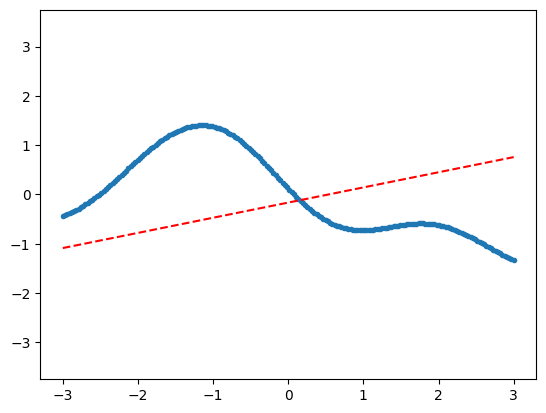

In [47]:
# Plot the sample
plt.scatter(grid, vals, marker=".")
plt.plot(grid, mean(grid), color='red', linestyle="--", label='True mean')
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-max(kern_priors["variance"])*1.5, max(kern_priors["variance"])*1.5)
plt.show()

In [48]:
emp_var = jnp.mean((vals - mean(grid))**2)  # Variance around true mean
emp_var

Array(1.6114498, dtype=float64)

In [49]:
jnp.var(vals)  # Variance around empirical mean

Array(0.68083814, dtype=float64)

In [50]:
slps = jnp.linspace(mean_priors["slope"][0]-2*mean_priors["slope"][1], mean_priors["slope"][0]+2*mean_priors["slope"][1], 50)
ints = jnp.linspace(mean_priors["intercept"][0]-2*mean_priors["intercept"][1], mean_priors["intercept"][0]+2*mean_priors["intercept"][1], 50)

In [51]:
llh_from_hps = jit(lambda s, i: mvn_nll(grid, vals[:, None], AffineMean(slope=s, intercept=i)(grid)[None, :], kern(grid)[None, :, :], jitter=nll_jitter).squeeze())

In [52]:
llh_values = vmap(vmap(llh_from_hps, in_axes=(0, None)), in_axes=(None, 0))(slps, ints)
llh_grads =  vmap(vmap(grad(llh_from_hps, argnums=(0, 1)), in_axes=(0, None)), in_axes=(None, 0))(slps, ints)
llh_values.shape, llh_grads[0].shape,  llh_grads[1].shape

((50, 50), (50, 50), (50, 50))

In [53]:
orig_slope = mean.slope.item()
orig_intercept = mean.intercept.item()
intercept_opt, slope_opt = jnp.unravel_index(jnp.argmin(llh_values), llh_values.shape)

In [54]:
orig_slope, slps[slope_opt].item(), orig_intercept, ints[intercept_opt].item()

(0.3076449244530506,
 -0.1734693877551021,
 -0.16444711212138338,
 -0.18367346938775514)

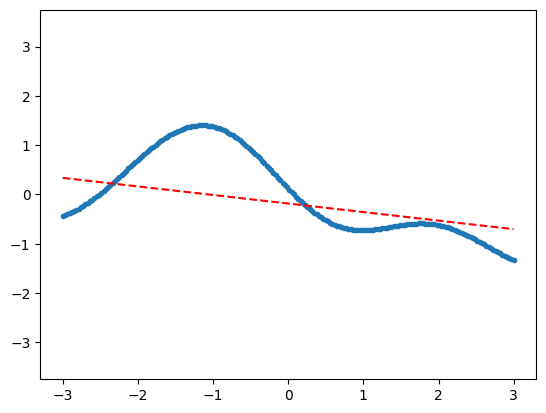

In [55]:
# Plot the sample
plt.scatter(grid, vals, marker=".")
plt.plot(grid, AffineMean(slope=slps[slope_opt], intercept=ints[intercept_opt])(grid), color='red', linestyle="--", label='True mean')
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-max(kern_priors["variance"])*1.5, max(kern_priors["variance"])*1.5)
plt.show()

In [56]:
llh_values[intercept_opt, slope_opt]

Array(-466.72982881, dtype=float64)

In [57]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['LLH values', 'intercept grads', 'slope grads'],
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}],],
    horizontal_spacing=0.05,
    vertical_spacing=0.1,
)

# --- VALUES ---

fig.add_trace(go.Surface(x=slps, y=ints, z=np.asarray(llh_values), showscale=False, colorscale='Viridis'), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=[orig_slope], y=[orig_intercept], z=[llh_from_hps(orig_slope, orig_intercept)],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=[slps[slope_opt].item()], y=[ints[intercept_opt].item()], z=[llh_values[intercept_opt, slope_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Mean optimal (slope={slps[slope_opt].item():.2f}, intercept={ints[intercept_opt].item():.2f})',
    showlegend=False,
), row=1, col=1)

# --- GRADS (slope) ---

fig.add_trace(go.Surface(x=slps, y=ints, z=np.asarray(llh_grads[1]), showscale=False, colorscale='Viridis'), row=1, col=2)

fig.add_trace(go.Surface(x=slps, y=ints, z=np.asarray(jnp.zeros_like(llh_grads[1])), showscale=False, colorscale='Viridis'), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=[orig_slope], y=[orig_intercept], z=[grad(llh_from_hps, argnums=(0, 1))(orig_slope, orig_intercept)[1]],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=[slps[slope_opt].item()], y=[ints[intercept_opt].item()], z=[llh_grads[1][intercept_opt, slope_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Mean optimal (slope={slps[slope_opt].item():.2f}, intercept={ints[intercept_opt].item():.2f})',
    showlegend=False,
), row=1, col=2)

# --- GRADS (intercept) ---

fig.add_trace(go.Surface(x=slps, y=ints, z=np.asarray(llh_grads[0]), showscale=False, colorscale='Viridis'), row=1, col=3)

fig.add_trace(go.Surface(x=slps, y=ints, z=np.asarray(jnp.zeros_like(llh_grads[0])), showscale=False, colorscale='Viridis'), row=1, col=3)

fig.add_trace(go.Scatter3d(
    x=[orig_slope], y=[orig_intercept], z=[grad(llh_from_hps, argnums=(0, 1))(orig_slope, orig_intercept)[0]],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=3)

fig.add_trace(go.Scatter3d(
    x=[slps[slope_opt].item()], y=[ints[intercept_opt].item()], z=[llh_grads[0][intercept_opt, slope_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
	name=f'Mean optimal (slope={slps[slope_opt].item():.2f}, intercept={ints[intercept_opt].item():.2f})',
    showlegend=False,
), row=1, col=3)

fig.update_layout(
    title='NLL values and grads',
    scene =dict(xaxis_title='slope', yaxis_title='intercept', zaxis_title='NLL values', xaxis_autorange='reversed', yaxis_autorange='reversed'),
    scene2=dict(xaxis_title='slope', yaxis_title='intercept', zaxis_title='NLL grads - intercept', xaxis_autorange='reversed', yaxis_autorange='reversed'),
    scene3=dict(xaxis_title='slope', yaxis_title='intercept', zaxis_title='NLL grads - slope', xaxis_autorange='reversed', yaxis_autorange='reversed'),
	height=700
)

fig.show()

### Multi-sample

In [58]:
nb_samples = 1000
key, subkey_1, subkey_2, subkey_3 = jr.split(key, 4)

In [59]:
kern = VarianceKernel(variance=1.) * SEKernel(length_scale=1.)
kern = BatchModule(kern, batch_size=nb_samples, batch_in_axes=0, batch_over_inputs=False)  # Distinct HPs in each kernel
kern = sample_hps_from_normal_priors(subkey_1, kern, kern_priors)

# Ensure positivity of variance and length-scales
kern = kern.replace(inner=kern.inner.replace(left=kern.inner.left.replace(variance=jnp.abs(kern.inner.left.variance))))
kern = kern.replace(inner=kern.inner.replace(right=kern.inner.right.replace(length_scale=jnp.abs(kern.inner.right.length_scale))))

mean = AffineMean(slope=0., intercept=0.)
mean = BatchModule(mean, batch_size=nb_samples, batch_in_axes=0, batch_over_inputs=False)
mean = sample_hps_from_normal_priors(subkey_2, mean, mean_priors)
print(f"{kern}\n{mean}")

VarianceKernel(variance=[2.52 ± 0.76]₁₀₀₀) * SEKernel(length_scale=[1.49 ± 0.50]₁₀₀₀)
AffineMean(slope=[0.01 ± 0.25]₁₀₀₀, intercept=[0.05 ± 1.53]₁₀₀₀)


In [60]:
subkeys = jr.split(subkey_3, nb_samples)
samples = vmap(lambda k, mu, cov: sample_gp(k, mu, cov, jitter=sample_jitter))(subkeys, mean(grid), kern(grid))
samples.shape

(1000, 200)

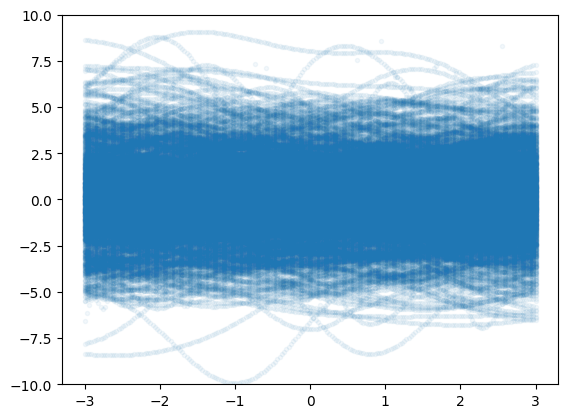

In [61]:
# Plot the sample
plt.scatter(jnp.broadcast_to(grid.T, samples.shape), samples, marker=".", alpha=0.05)
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-10, 10)
plt.show()

In [62]:
llh_from_hps = jit(lambda smp, s, i, cov: mvn_nll(grid, smp[:, None], AffineMean(slope=s, intercept=i)(grid)[None, :], cov[None, :, :], jitter=nll_jitter).squeeze())

In [63]:
kern_covs = kern(grid)  # (nb_samples, nb_points, nb_points)
llh_values = jit(vmap(
    lambda smp, cov: vmap(vmap(llh_from_hps, in_axes=(None, 0, None, None)), in_axes=(None, None, 0, None))(smp, slps, ints, cov)
))(samples, kern_covs)
llh_values.shape

(1000, 50, 50)

In [64]:
intercept_opt, slope_opt = vmap(lambda lvs: jnp.unravel_index(jnp.argmin(lvs), lvs.shape))(llh_values)
intercept_opt.shape, slope_opt.shape

((1000,), (1000,))

In [65]:
opti_slopes = slps[slope_opt]
orig_slopes = mean.inner.slope
opti_intercepts = ints[intercept_opt]
orig_intercepts = mean.inner.intercept
opti_slopes.shape, orig_slopes.shape, opti_intercepts.shape, orig_intercepts.shape

((1000,), (1000,), (1000,), (1000,))

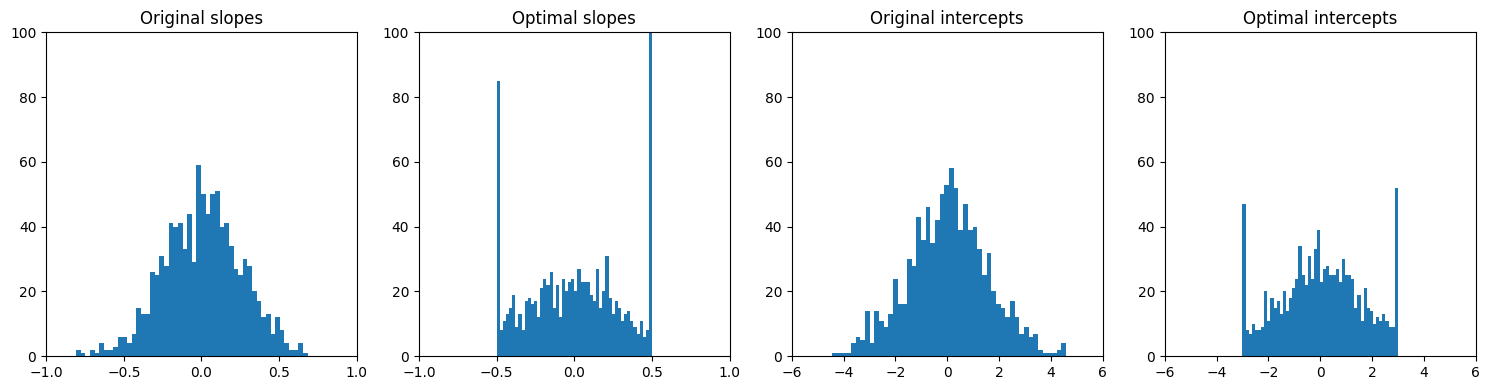

In [66]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

ax[0].hist(orig_slopes, bins=50)
ax[0].set_title("Original slopes")
ax[0].set_xlim(mean_priors["slope"][0]-4*mean_priors["slope"][1], mean_priors["slope"][0]+4*mean_priors["slope"][1])
ax[0].set_ylim(0, 100)

ax[1].hist(opti_slopes, bins=50)
ax[1].set_title("Optimal slopes")
ax[1].set_xlim(mean_priors["slope"][0]-4*mean_priors["slope"][1], mean_priors["slope"][0]+4*mean_priors["slope"][1])
ax[1].set_ylim(0, 100)

ax[2].hist(orig_intercepts, bins=50)
ax[2].set_title("Original intercepts")
ax[2].set_xlim(mean_priors["intercept"][0]-4*mean_priors["intercept"][1], mean_priors["intercept"][0]+4*mean_priors["intercept"][1])
ax[2].set_ylim(0, 100)

ax[3].hist(opti_intercepts, bins=50)
ax[3].set_title("Optimal intercepts")
ax[3].set_xlim(mean_priors["intercept"][0]-4*mean_priors["intercept"][1], mean_priors["intercept"][0]+4*mean_priors["intercept"][1])
ax[3].set_ylim(0, 100)

plt.tight_layout()
plt.show()

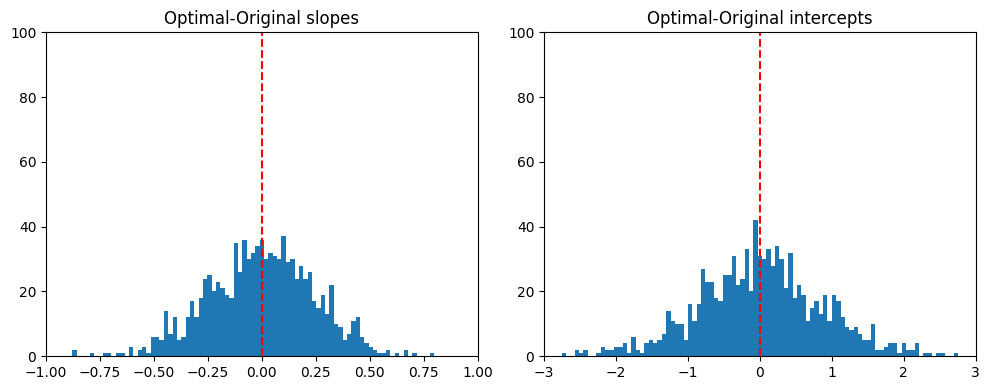

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

nb_bins = 100
slp_low, slp_high = -1., 1.
int_low, int_high = -3., 3.
slp_bins = jnp.linspace(slp_low, slp_high, nb_bins)
int_bins = jnp.linspace(int_low, int_high, nb_bins)

ax[0].hist(opti_slopes - orig_slopes, bins=slp_bins)
ax[0].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[0].set_title("Optimal-Original slopes")
ax[0].set_xlim(slp_low, slp_high)
ax[0].set_ylim(0, 100)

ax[1].hist(opti_intercepts - orig_intercepts, bins=int_bins)
ax[1].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[1].set_title("Optimal-Original intercepts")
ax[1].set_xlim(int_low, int_high)
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

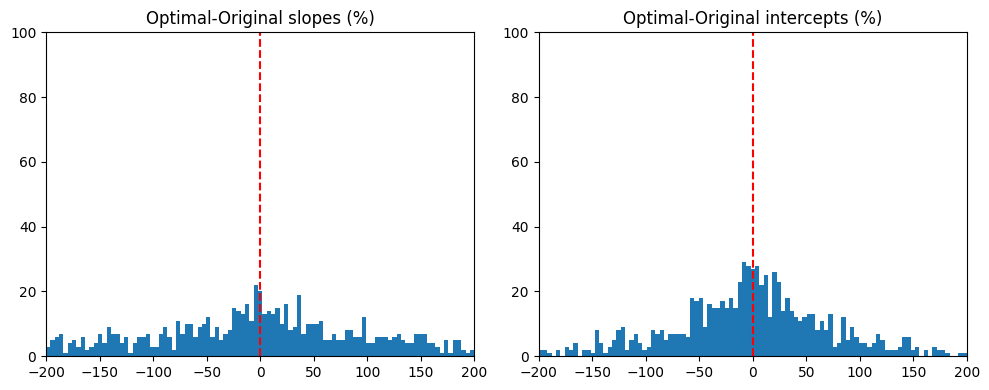

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

low, high = -200, 200
bins = jnp.linspace(low, high, 100)

ax[0].hist((opti_slopes - orig_slopes)/jnp.abs(orig_slopes)*100, bins=bins)
ax[0].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[0].set_title("Optimal-Original slopes (%)")
ax[0].set_xlim(low, high)
ax[0].set_ylim(0, 100)

ax[1].hist((opti_intercepts - orig_intercepts)/jnp.abs(orig_intercepts)*100, bins=bins)
ax[1].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[1].set_title("Optimal-Original intercepts (%)")
ax[1].set_xlim(low, high)
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

---